# WATER PROBABILITY PREDICTION

#### IMPORT THE LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score,roc_curve,roc_auc_score,roc_curve,auc,precision_score,recall_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import warnings
import joblib
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv("water_potability.csv")
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890456,20791.31898,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.05786,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.54173,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,363.266516,18.436525,100.341674,4.628771,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


(3276, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [6]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690300,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833605,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762125,8.114887,359.950170,481.792305,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196010,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [3]:
# to check the number of null values in each column
df.isnull().sum() 
# Handle missing values with median imputation
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median") # strong against outliers
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print(df_imputed.isnull().sum())

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [5]:
joblib.dump(imputer,"imputer.pkl")

['imputer.pkl']

### EDA VISUALIZATION

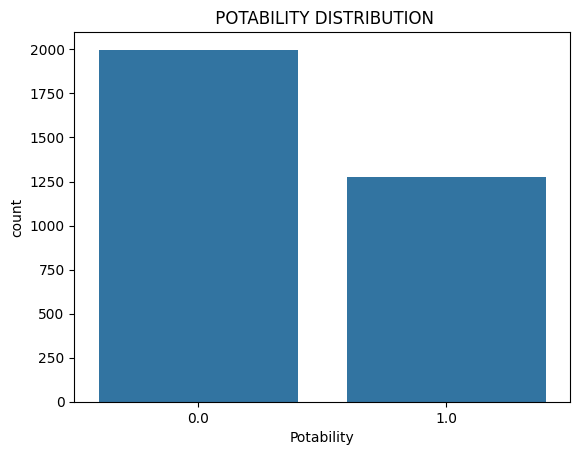

In [6]:
sns.countplot(x='Potability',data=df_imputed)
plt.title(" POTABILITY DISTRIBUTION")
plt.show()

### TO CHECK DISTRIBUTIONS

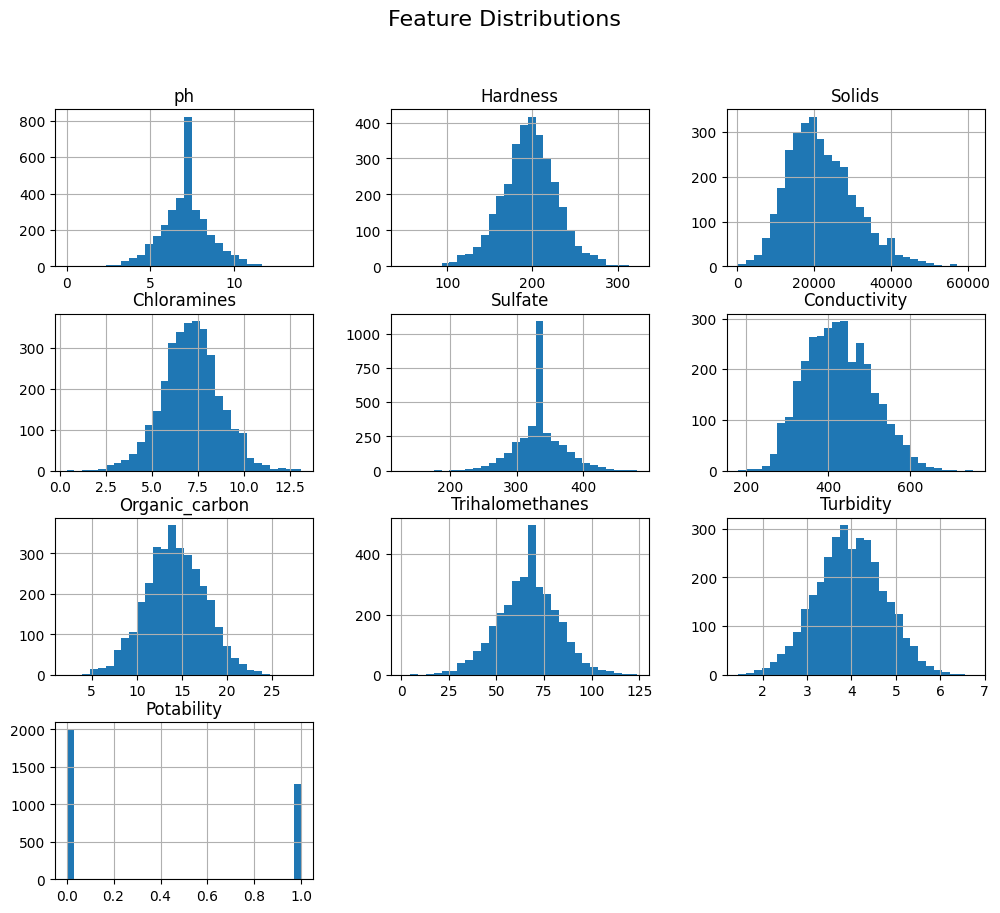

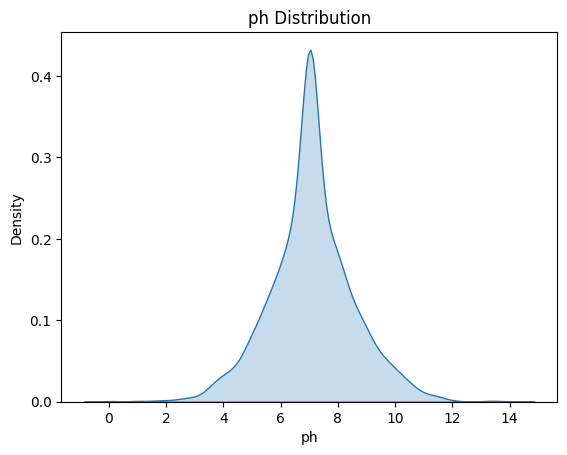

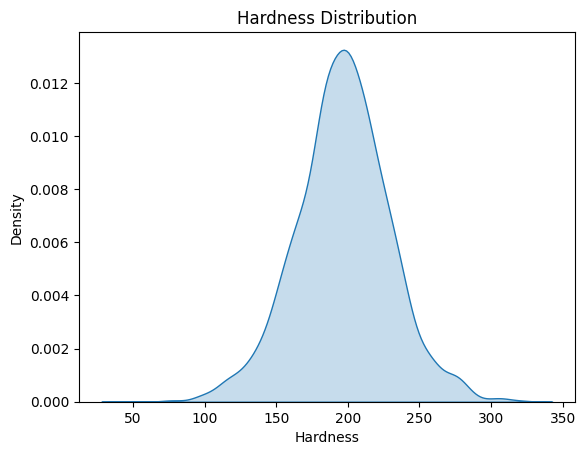

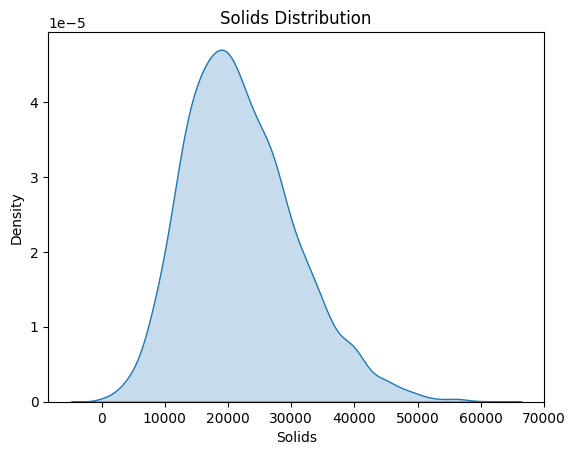

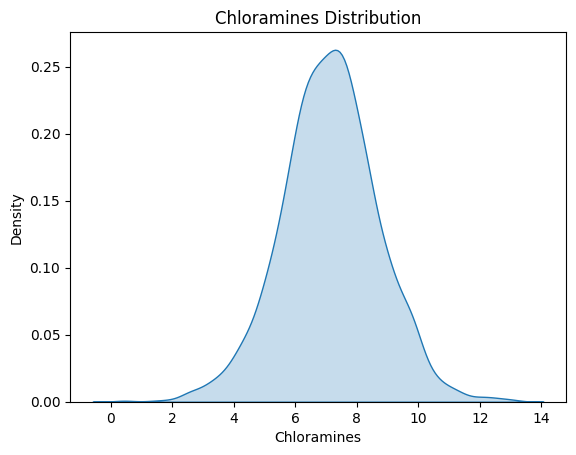

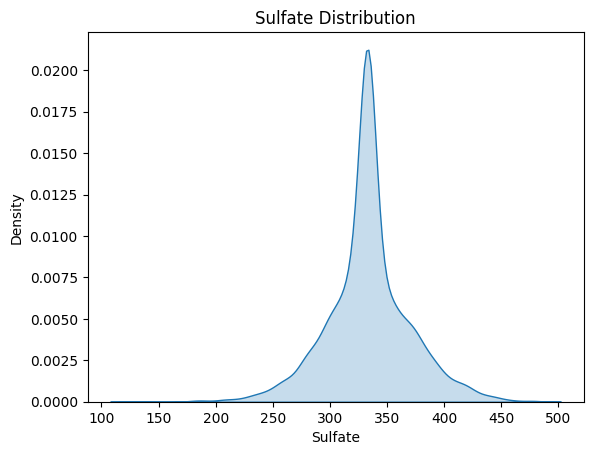

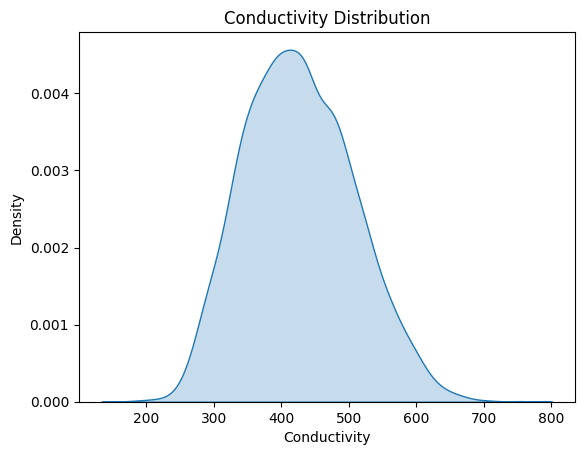

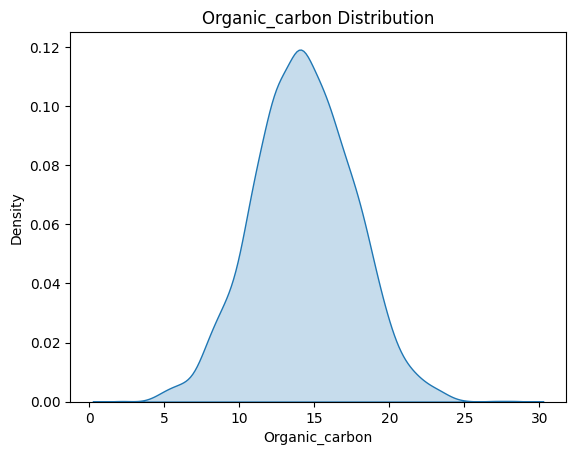

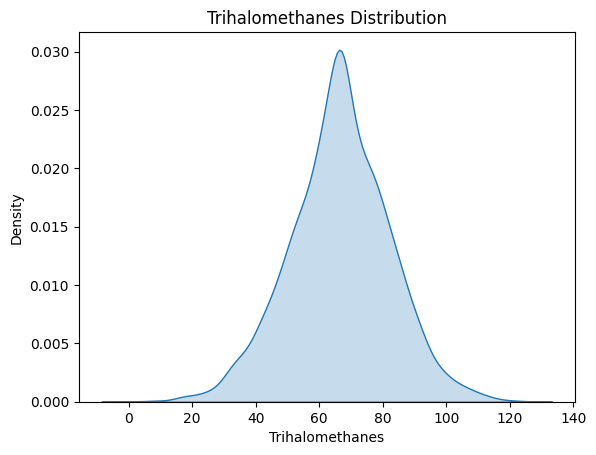

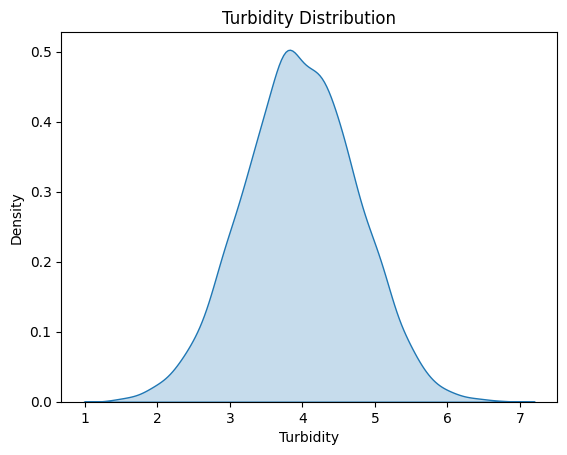

In [7]:
df_imputed.hist(figsize=(12,10), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

# Density plots for smoother view
for col in df_imputed.drop("Potability", axis=1).columns:
    sns.kdeplot(df_imputed[col], shade=True)
    plt.title(f"{col} Distribution")
    plt.show()

### ADRESS OUTLIERS

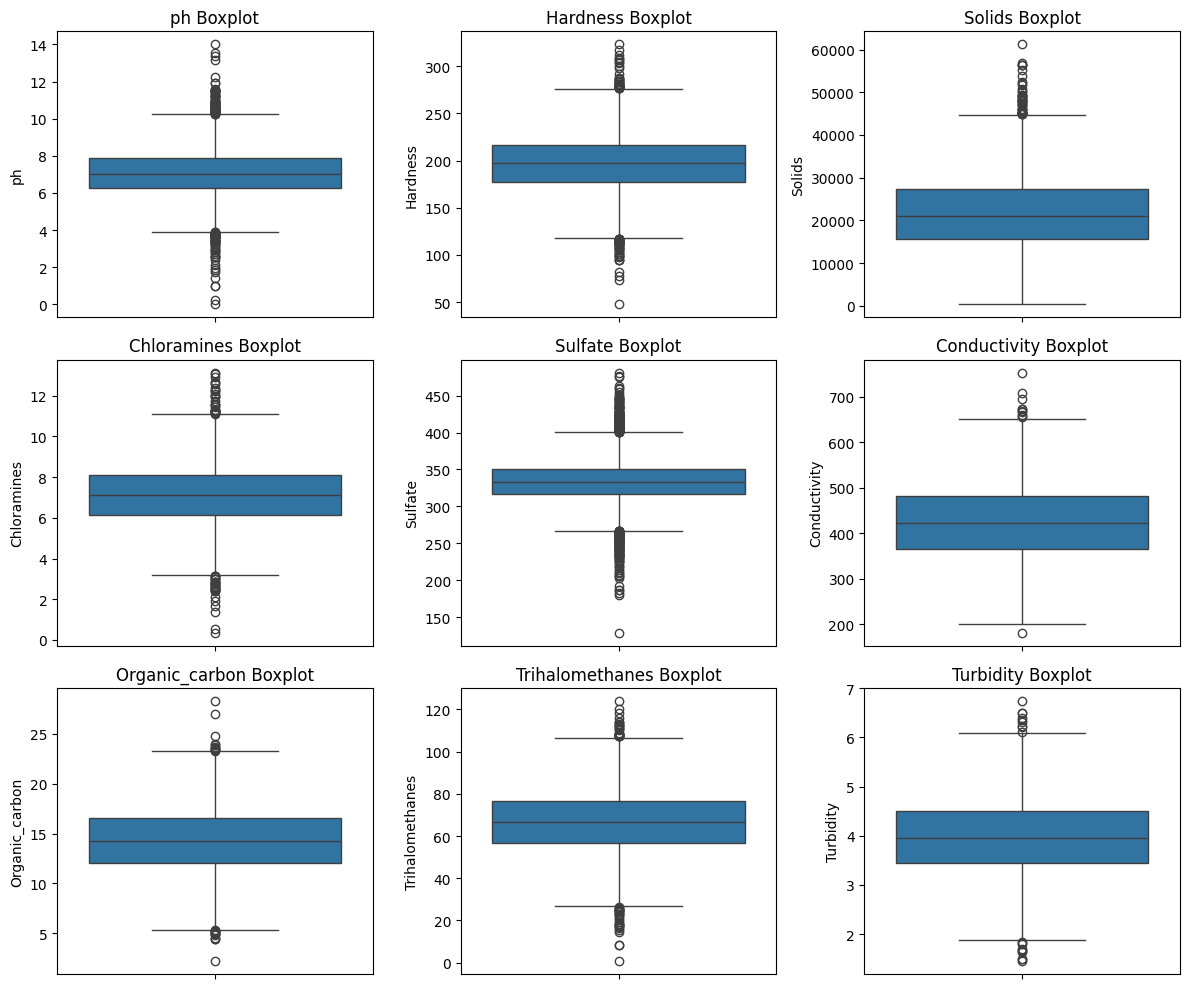

In [8]:
# Boxplots to visualize outliers
plt.figure(figsize=(12,10))
for i, col in enumerate(df_imputed.drop("Potability", axis=1).columns, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df_imputed[col])
    plt.title(f"{col} Boxplot")
plt.tight_layout()
plt.show()

# Optional: log-transform skewed features (e.g., Solids)
import numpy as np
df_imputed["Solids_log"] = np.log1p(df_imputed["Solids"])

### TO SCALE FEATURES

In [9]:
from sklearn.preprocessing import StandardScaler

X = df_imputed.drop("Potability", axis=1)
y = df_imputed["Potability"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (3276, 10)


In [10]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

### CORRELATION ANALYSIS

This shows how strongly each feature relates to Potability and highlights redundant pairs (e.g., Solids vs. Conductivity).


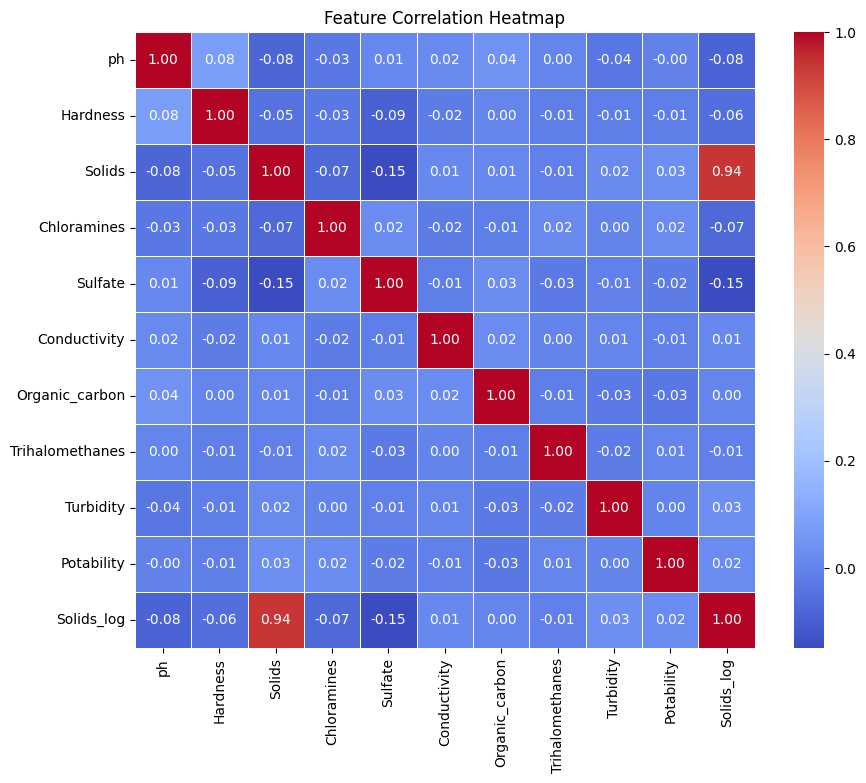

Potability         1.000000
Solids             0.033743
Chloramines        0.023779
Solids_log         0.021568
Trihalomethanes    0.006887
Turbidity          0.001581
ph                -0.003014
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.020476
Organic_carbon    -0.030001
Name: Potability, dtype: float64


In [11]:
# Correlation matrix
corr = df_imputed.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Check correlation with target
print(corr["Potability"].sort_values(ascending=False))

### FEATURE TRANSFORMATIONS

In [15]:
df_imputed["Solids_log"] = np.log1p(df_imputed["Solids"])
df_imputed["Trihalomethanes_log"] = np.log1p(df_imputed["Trihalomethanes"])
# Ratio of conductivity to hardness
df_imputed["Cond_Hardness_ratio"] = df_imputed["Conductivity"] / (df_imputed["Hardness"] + 1e-6)
print(df_imputed[["Cond_Hardness_ratio"]].describe())
# Normalized turbidity
df_imputed["Turbidity_norm"] = (df_imputed["Turbidity"] - df_imputed["Turbidity"].mean()) / df_imputed["Turbidity"].std()
print(df_imputed[["Turbidity_norm"]].describe())
# Categorize pH levels
df_imputed["ph_category"] = pd.cut(df_imputed["ph"], bins=[0,6.5,8.5,14], labels=["acidic","neutral","alkaline"])
print(df_imputed["ph_category"].value_counts())

       Cond_Hardness_ratio
count          3276.000000
mean              2.242608
std               0.635385
min               0.964703
25%               1.791583
50%               2.152362
75%               2.576633
max              10.546592
       Turbidity_norm
count    3.276000e+03
mean    -3.426916e-16
std      1.000000e+00
min     -3.225068e+00
25%     -6.754064e-01
50%     -1.506775e-02
75%      6.836823e-01
max      3.552379e+00
ph_category
neutral     1819
acidic       967
alkaline     489
Name: count, dtype: int64


       Cond_Hardness_ratio
count          3276.000000
mean              2.242608
std               0.635385
min               0.964703
25%               1.791583
50%               2.152362
75%               2.576633
max              10.546592
       Turbidity_norm
count    3.276000e+03
mean    -3.426916e-16
std      1.000000e+00
min     -3.225068e+00
25%     -6.754064e-01
50%     -1.506775e-02
75%      6.836823e-01
max      3.552379e+00


ph_category
neutral     1819
acidic       967
alkaline     489
Name: count, dtype: int64


### FEATURE IMPORTANCE

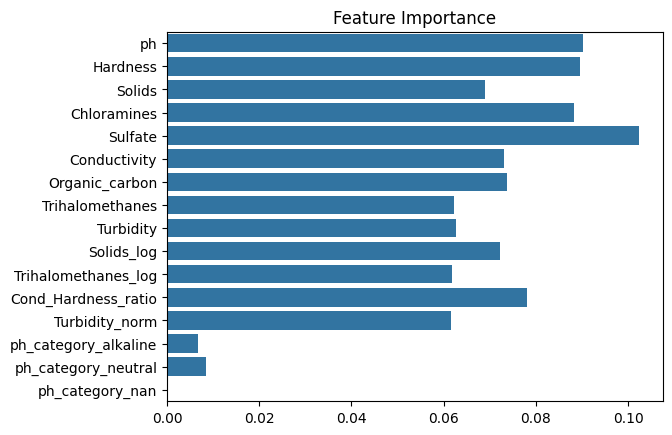

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Separate target
y = df_imputed["Potability"]
X = df_imputed.drop("Potability", axis=1)

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns
numeric_cols = X.select_dtypes(include=["float64", "int64"]).columns

# Preprocessor: scale numeric, encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)

# Build pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

# Fit model
pipeline.fit(X, y)

# Feature importance (after preprocessing)
model = pipeline.named_steps["model"]
importances = model.feature_importances_

# Get feature names after transformation
feature_names = (
    list(numeric_cols) +
    list(pipeline.named_steps["preprocessor"].transformers_[1][1].get_feature_names_out(categorical_cols))
)


sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance")
plt.show()

In [20]:
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(pipeline, 'pipeline.pkl')

['pipeline.pkl']

### ENCODING

In [21]:
from sklearn.preprocessing import OneHotEncoder

# Separate target
y = df_imputed["Potability"]
X = df_imputed.drop("Potability", axis=1)

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=["object","category"]).columns
numeric_cols = X.select_dtypes(include=["float64","int64"]).columns

# One-hot encode categorical features
if len(categorical_cols) > 0:
    encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
    encoded = pd.DataFrame(
        encoder.fit_transform(X[categorical_cols]),
        columns=encoder.get_feature_names_out(categorical_cols)
    )
    X = pd.concat([X[numeric_cols].reset_index(drop=True),
                   encoded.reset_index(drop=True)], axis=1)

In [22]:
joblib.dump(encoder, 'ohe.pkl')

['ohe.pkl']

### HANDLING CLASS IMBALANCE USING SMOTE

In [16]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE to training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check class distribution before and after
print("Original training distribution:\n", y_train.value_counts())
print("Resampled training distribution:\n", pd.Series(y_train_resampled).value_counts())

Original training distribution:
 Potability
0.0    1598
1.0    1022
Name: count, dtype: int64
Resampled training distribution:
 Potability
0.0    1598
1.0    1598
Name: count, dtype: int64


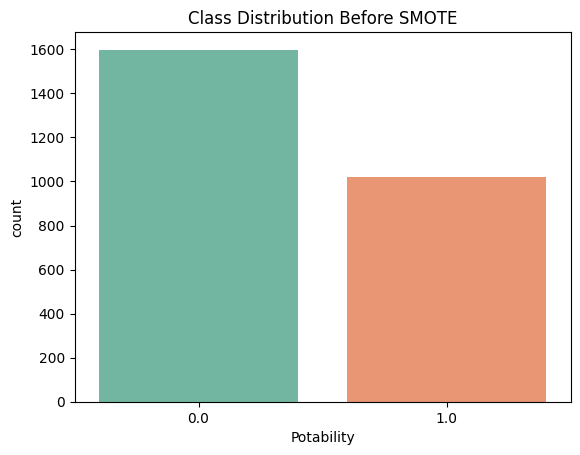

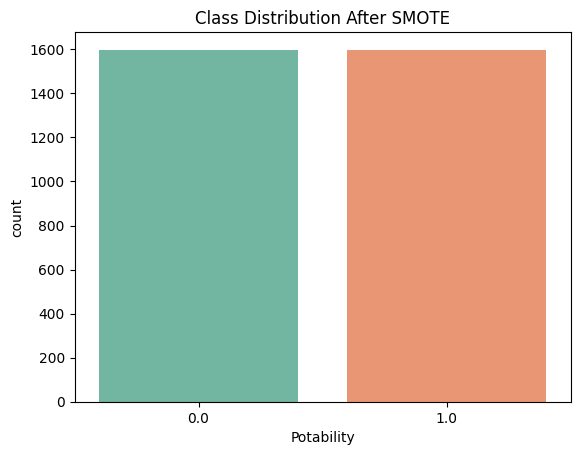

In [17]:
# Before SMOTE
sns.countplot(x=y_train, palette="Set2")
plt.title("Class Distribution Before SMOTE")
plt.show()

# After SMOTE
sns.countplot(x=y_train_resampled, palette="Set2")
plt.title("Class Distribution After SMOTE")
plt.show()

## MODEL SELECTION AND TRAINING


### RANDOM FOREST

In [ ]:
#Random Forest
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "criterion": ['gini','entropy']
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), 
                       rf_params, 
                       cv=5, 
                       scoring="accuracy", 
                       n_jobs=-1)

rf_grid.fit(X_train_resampled, y_train_resampled)

print("Best Random Forest params:", rf_grid.best_params_)
print("Best CV score:", rf_grid.best_score_)

y_pred_rf = rf_grid.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Best Random Forest params: {'criterion': 'gini', 'max_depth': 20, 'n_estimators': 300}
Best CV score: 0.708714299687011
Accuracy: 0.6509146341463414
              precision    recall  f1-score   support

         0.0       0.69      0.78      0.73       400
         1.0       0.57      0.46      0.51       256

    accuracy                           0.65       656
   macro avg       0.63      0.62      0.62       656
weighted avg       0.64      0.65      0.64       656



### KNN

In [ ]:
#KNN
knn_params = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring="accuracy", n_jobs=-1)
knn_grid.fit(X_train_resampled, y_train_resampled)

print("Best KNN params:", knn_grid.best_params_)
print("Best CV score:", knn_grid.best_score_)


y_pred_knn = knn_grid.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


Best KNN params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Best CV score: 0.6520764866979656
Accuracy: 0.5365853658536586
              precision    recall  f1-score   support

         0.0       0.64      0.56      0.59       400
         1.0       0.42      0.50      0.46       256

    accuracy                           0.54       656
   macro avg       0.53      0.53      0.53       656
weighted avg       0.55      0.54      0.54       656



### DECISION TREE

In [ ]:
# Decision Tree
dt_params = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring="accuracy", n_jobs=-1)
dt_grid.fit(X_train_resampled, y_train_resampled)

print("Best Decision Tree params:", dt_grid.best_params_)
print("Best CV score:", dt_grid.best_score_)

y_pred_dt = dt_grid.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Best Decision Tree params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
Best CV score: 0.6386213810641628
Accuracy: 0.5685975609756098
              precision    recall  f1-score   support

         0.0       0.64      0.66      0.65       400
         1.0       0.45      0.43      0.44       256

    accuracy                           0.57       656
   macro avg       0.54      0.54      0.54       656
weighted avg       0.57      0.57      0.57       656



### XGBOOST

In [ ]:
#XGBooost
xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
                        xgb_params, cv=5, scoring="accuracy", n_jobs=-1)
xgb_grid.fit(X_train_resampled, y_train_resampled)

print("Best XGBoost params:", xgb_grid.best_params_)
print("Best CV score:", xgb_grid.best_score_)


y_pred_xgb = xgb_grid.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Best XGBoost params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV score: 0.7024466940532083
Accuracy: 0.6158536585365854
              precision    recall  f1-score   support

         0.0       0.67      0.73      0.70       400
         1.0       0.51      0.43      0.47       256

    accuracy                           0.62       656
   macro avg       0.59      0.58      0.58       656
weighted avg       0.61      0.62      0.61       656



### SVM

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Define a smaller parameter grid for speed
svc_params = {
    "C": [ 0.1,1],          
    "kernel": ["rbf"],  
    "gamma": ["scale"]        
}

# Grid search
svc_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid=svc_params,
    cv=3,                      # fewer folds for speed
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

# Fit on training data
svc_grid.fit(X_train_resampled, y_train_resampled)
print("Best SVC params:", svc_grid.best_params_)
print("Best CV score:", svc_grid.best_score_)
# Evaluate on test set
y_pred_svc = svc_grid.best_estimator_.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc))

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best SVC params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score: 0.5084477681179845
Accuracy: 0.5929878048780488
              precision    recall  f1-score   support

         0.0       0.62      0.88      0.73       400
         1.0       0.44      0.14      0.22       256

    accuracy                           0.59       656
   macro avg       0.53      0.51      0.47       656
weighted avg       0.55      0.59      0.53       656



### COMPARISON TABLE OF TUNED MODELS
#### CONFUSION MATRIX
#### ROC-AUC CURVES
#### ROC-AUC INDIVIDUAL CURVES
#### MODEL COMARISON BAR CHART
#### INDIVIDUAL FEATURE IMPORTANCE PLOT
#### COMPARATIVE HEAPMAP

In [30]:
from sklearn.preprocessing import MinMaxScaler

# --- Models dictionary (replace with your tuned models) ---
best_models = {
    "SVC": svc_grid.best_estimator_,
    "RandomForest": rf_grid.best_estimator_,
    "KNN": knn_grid.best_estimator_,
    "DecisionTree": dt_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

summary = []

# --- Evaluation loop ---
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    
    # Probabilities for ROC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:,1]
    else:
        y_score = model.decision_function(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = auc(*roc_curve(y_test, y_score)[:2])
    
    summary.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc_auc
    })
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=[0,1], yticklabels=[0,1])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"confusion_matrix_{name}.png", dpi=300, bbox_inches="tight")
    plt.close()
   
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.2f})")
    plt.plot([0,1],[0,1],"k--", lw=2)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend(loc="lower right")
    plt.savefig(f"roc_curve_{name}.png", dpi=300, bbox_inches="tight")
    plt.close()

# --- Summary table ---
summary_df = pd.DataFrame(summary)
print(summary_df)
summary_df.to_csv("model_evaluation_summary.csv", index=False)

# --- Combined ROC Curve ---
plt.figure(figsize=(8,6))
for name, model in best_models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:,1]
    else:
        y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],"k--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models")
plt.legend(loc="lower right")
plt.savefig("roc_curves_all_models.png", dpi=300, bbox_inches="tight")
plt.close()

# --- Bar Chart Comparison ---
summary_df.set_index("Model")[["Accuracy","F1","ROC-AUC"]].plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(title="Metrics")
plt.xticks(rotation=0)
plt.savefig("model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.close()

# --- Feature Importance Analysis ---
tree_models = {
    "RandomForest": rf_grid.best_estimator_,
    "DecisionTree": dt_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

feature_names = X_train_resampled.columns
all_importances = pd.DataFrame({"Feature": feature_names})

# Collect and normalize feature importances
for name, model in tree_models.items():
    importances = model.feature_importances_.reshape(-1,1)
    scaler = MinMaxScaler()
    normalized = scaler.fit_transform(importances).flatten()
    all_importances[name] = normalized
    
    # Individual plots
    feat_imp = pd.DataFrame({
        "Feature": feature_names,
        "Importance": normalized
    }).sort_values(by="Importance", ascending=False)
    
    plt.figure(figsize=(8,6))
    sns.barplot(x="Importance", y="Feature", data=feat_imp.head(10), palette="viridis")
    plt.title(f"Top 10 Feature Importances - {name}")
    plt.xlabel("Normalized Importance")
    plt.ylabel("Feature")
    plt.savefig(f"feature_importance_{name}.png", dpi=300, bbox_inches="tight")
    plt.close()

# Save normalized importances to CSV
all_importances.to_csv("feature_importance_summary_normalized.csv", index=False)

# --- Comparative Heatmap ---
all_importances.set_index("Feature", inplace=True)
plt.figure(figsize=(12,8))
sns.heatmap(all_importances, cmap="viridis", cbar=True)
plt.title("Normalized Feature Importances Across Tree-Based Models")
plt.xlabel("Model")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance_heatmap.png", dpi=300, bbox_inches="tight")
plt.close()

          Model  Accuracy  Precision    Recall        F1   ROC-AUC
0           SVC  0.592988   0.435294  0.144531  0.217009  0.511338
1  RandomForest  0.650915   0.565217  0.457031  0.505400  0.651743
2           KNN  0.536585   0.421569  0.503906  0.459075  0.537485
3  DecisionTree  0.568598   0.445783  0.433594  0.439604  0.547095
4       XGBoost  0.615854   0.509259  0.429688  0.466102  0.626152


#### MODEL PERFORMANCE COMPARISON

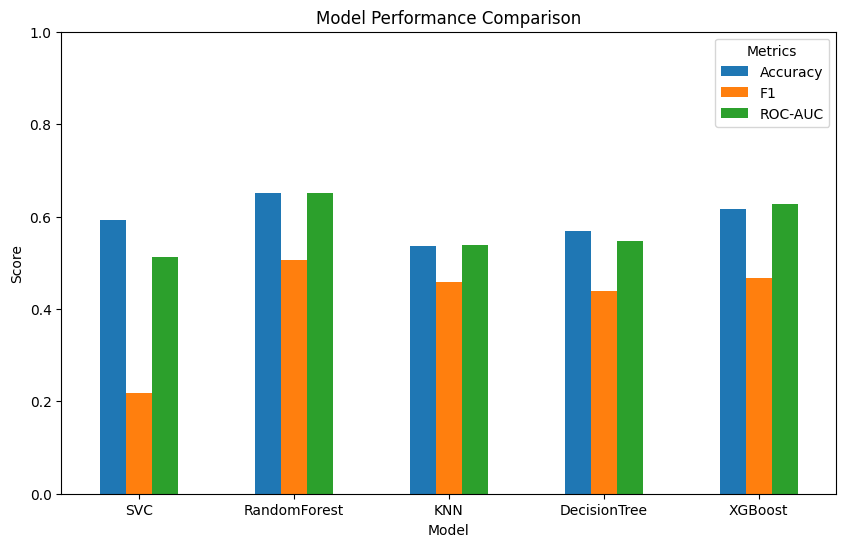

In [31]:
import matplotlib.pyplot as plt

# Assuming you already created summary_df with Accuracy, F1, ROC-AUC
metrics = ["Accuracy", "F1", "ROC-AUC"]

# Plot each metric side by side
summary_df.set_index("Model")[metrics].plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)  # metrics are between 0 and 1
plt.legend(title="Metrics")
plt.xticks(rotation=0)
plt.show()

# Save plot
plt.savefig("model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.close()

### FEATURE IMPORTANCE FOR TREE BASED MODELS


Top Features for RandomForest:
 - Sulfate: 1.00
 - ph: 0.95
 - Chloramines: 0.89
 - Hardness: 0.81
 - Solids: 0.73


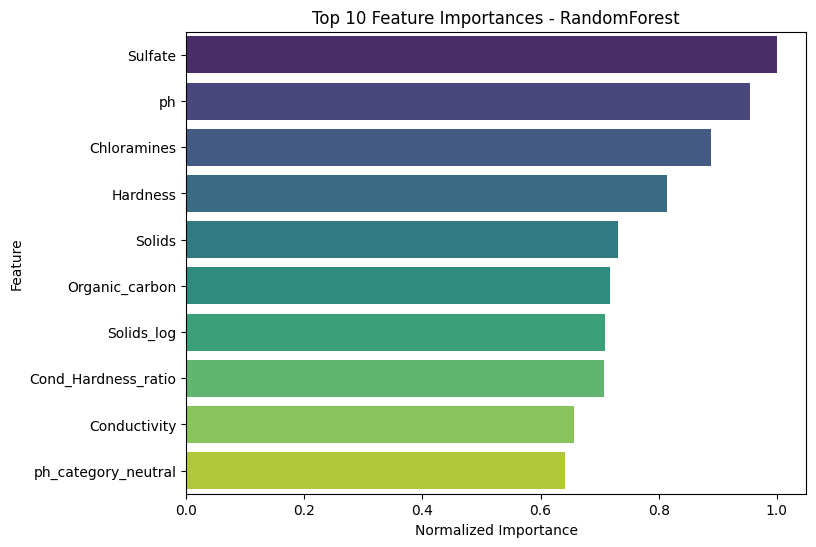


Top Features for DecisionTree:
 - ph_category_neutral: 1.00
 - Sulfate: 0.62
 - Chloramines: 0.50
 - ph: 0.45
 - Hardness: 0.44


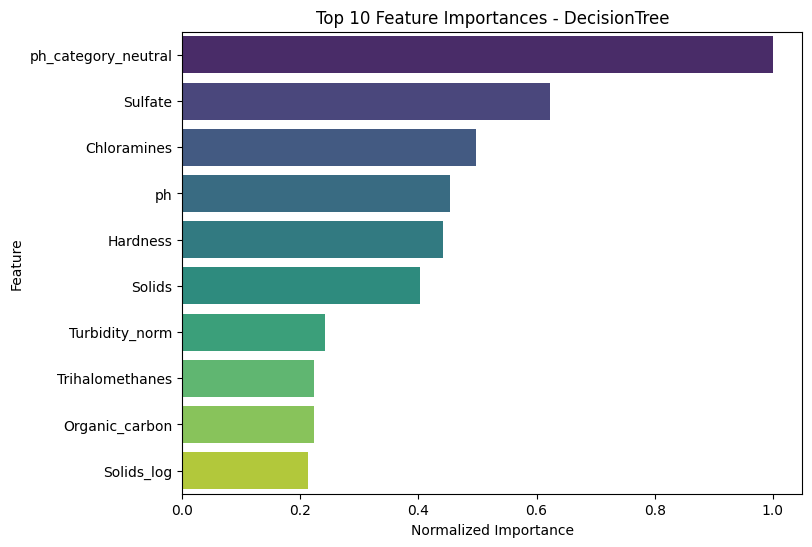


Top Features for XGBoost:
 - ph_category_neutral: 1.00
 - ph_category_alkaline: 0.50
 - Sulfate: 0.14
 - ph: 0.13
 - Hardness: 0.13


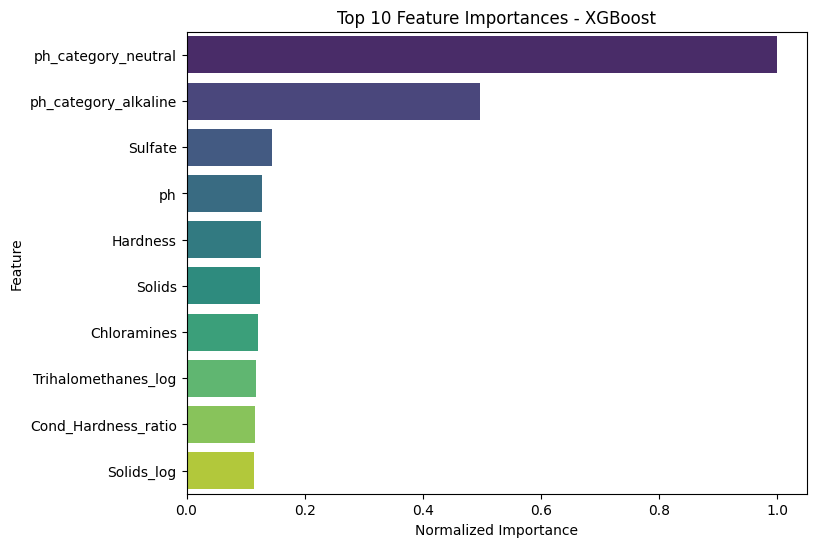

In [32]:
# --- Feature Importance Analysis ---
from sklearn.preprocessing import MinMaxScaler

tree_models = {
    "RandomForest": rf_grid.best_estimator_,
    "DecisionTree": dt_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

feature_names = X_train_resampled.columns
all_importances = pd.DataFrame({"Feature": feature_names})

for name, model in tree_models.items():
    # Normalize feature importances (0–1 scale)
    importances = model.feature_importances_.reshape(-1,1)
    normalized = MinMaxScaler().fit_transform(importances).flatten()
    all_importances[name] = normalized
    
    # Create DataFrame
    feat_imp = pd.DataFrame({
        "Feature": feature_names,
        "Importance": normalized
    }).sort_values(by="Importance", ascending=False)
    
    # Print narrative summary
    print(f"\nTop Features for {name}:")
    for f, s in zip(feat_imp.head(5)["Feature"], feat_imp.head(5)["Importance"]):
        print(f" - {f}: {s:.2f}")
    
    # Save numeric results
    feat_imp.to_csv(f"feature_importance_{name}.csv", index=False)
    
    # Plot top 10
    plt.figure(figsize=(8,6))
    sns.barplot(x="Importance", y="Feature", data=feat_imp.head(10), palette="viridis")
    plt.title(f"Top 10 Feature Importances - {name}")
    plt.xlabel("Normalized Importance")
    plt.ylabel("Feature")
    plt.savefig(f"feature_importance_{name}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

# Save combined normalized importances
all_importances.to_csv("feature_importance_summary_normalized.csv", index=False)



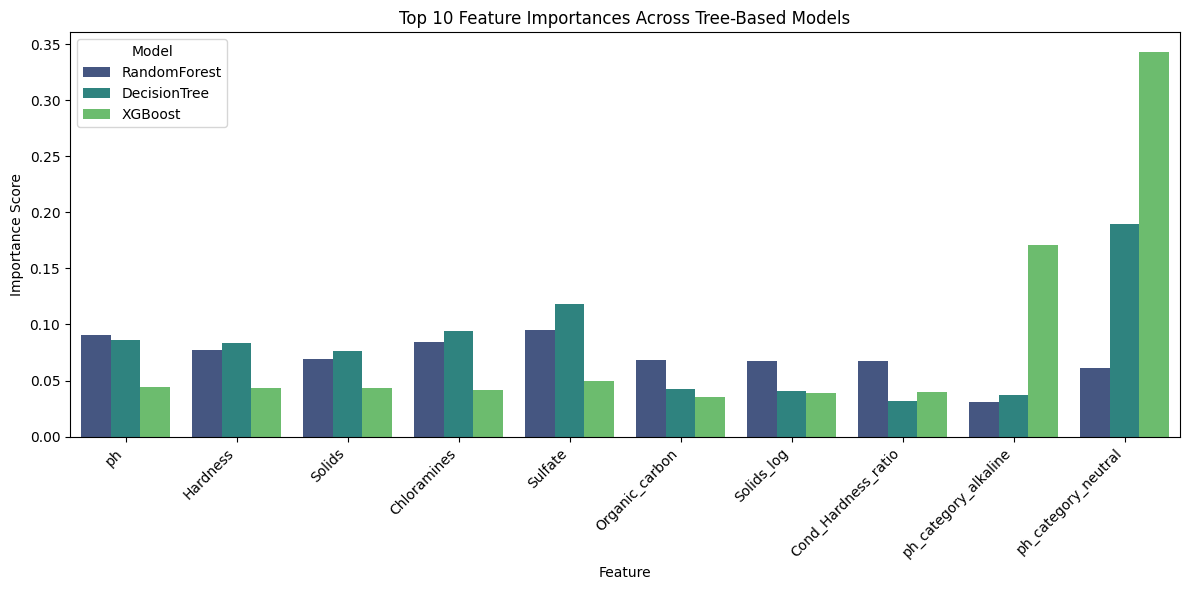

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tree-based models
tree_models = {
    "RandomForest": rf_grid.best_estimator_,
    "DecisionTree": dt_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

# Collect feature importances into one DataFrame
feature_names = X_train_resampled.columns
all_importances = pd.DataFrame({"Feature": feature_names})

for name, model in tree_models.items():
    all_importances[name] = model.feature_importances_

# Melt for plotting
melted = all_importances.melt(id_vars="Feature", var_name="Model", value_name="Importance")

# Plot top features across models
top_features = (
    melted.groupby("Feature")["Importance"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=melted[melted["Feature"].isin(top_features)],
    x="Feature", y="Importance", hue="Model", palette="viridis"
)
plt.title("Top 10 Feature Importances Across Tree-Based Models")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importance Score")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# Save plot
plt.savefig("feature_importance_comparison.png", dpi=300, bbox_inches="tight")
plt.close()



In [34]:
#feature importance summary table
import pandas as pd

# Tree-based models
tree_models = {
    "RandomForest": rf_grid.best_estimator_,
    "DecisionTree": dt_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

feature_names = X_train_resampled.columns
all_importances = pd.DataFrame({"Feature": feature_names})

# Collect feature importances
for name, model in tree_models.items():
    all_importances[name] = model.feature_importances_

# Save to CSV
all_importances.to_csv("feature_importance_summary.csv", index=False)

print("Feature importance values saved as feature_importance_summary.csv")

Feature importance values saved as feature_importance_summary.csv


In [35]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Tree-based models
tree_models = {
    "RandomForest": rf_grid.best_estimator_,
    "DecisionTree": dt_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

feature_names = X_train_resampled.columns
all_importances = pd.DataFrame({"Feature": feature_names})

# Collect and normalize feature importances
for name, model in tree_models.items():
    importances = model.feature_importances_.reshape(-1,1)
    scaler = MinMaxScaler()
    normalized = scaler.fit_transform(importances).flatten()
    all_importances[name] = normalized

# Save normalized importances to CSV
all_importances.to_csv("feature_importance_summary_normalized.csv", index=False)

print("Normalized feature importance values saved as feature_importance_summary_normalized.csv")

Normalized feature importance values saved as feature_importance_summary_normalized.csv


In [36]:
from sklearn.preprocessing import MinMaxScaler

# --- Models dictionary (replace with your tuned models) ---
best_models = {
    "SVC": svc_grid.best_estimator_,
    "RandomForest": rf_grid.best_estimator_,
    "KNN": knn_grid.best_estimator_,
    "DecisionTree": dt_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

summary = []

# --- Evaluation loop ---
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    
    # Probabilities for ROC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:,1]
    else:
        y_score = model.decision_function(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = auc(*roc_curve(y_test, y_score)[:2])
    
    summary.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc_auc
    })
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=[0,1], yticklabels=[0,1])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"confusion_matrix_{name}.png", dpi=300, bbox_inches="tight")
    plt.close()
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.2f})")
    plt.plot([0,1],[0,1],"k--", lw=2)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend(loc="lower right")
    plt.savefig(f"roc_curve_{name}.png", dpi=300, bbox_inches="tight")
    plt.close()

# --- Summary table ---
summary_df = pd.DataFrame(summary)
print(summary_df)
summary_df.to_csv("model_evaluation_summary.csv", index=False)

# --- Combined ROC Curve ---
plt.figure(figsize=(8,6))
for name, model in best_models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:,1]
    else:
        y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],"k--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models")
plt.legend(loc="lower right")
plt.savefig("roc_curves_all_models.png", dpi=300, bbox_inches="tight")
plt.close()

# --- Bar Chart Comparison ---
summary_df.set_index("Model")[["Accuracy","F1","ROC-AUC"]].plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(title="Metrics")
plt.xticks(rotation=0)
plt.savefig("model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.close()

# --- Feature Importance Analysis ---
tree_models = {
    "RandomForest": rf_grid.best_estimator_,
    "DecisionTree": dt_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

feature_names = X_train_resampled.columns
all_importances = pd.DataFrame({"Feature": feature_names})

# Collect and normalize feature importances
for name, model in tree_models.items():
    importances = model.feature_importances_.reshape(-1,1)
    scaler = MinMaxScaler()
    normalized = scaler.fit_transform(importances).flatten()
    all_importances[name] = normalized
    
    # Individual plots
    feat_imp = pd.DataFrame({
        "Feature": feature_names,
        "Importance": normalized
    }).sort_values(by="Importance", ascending=False)
    
    plt.figure(figsize=(8,6))
    sns.barplot(x="Importance", y="Feature", data=feat_imp.head(10), palette="viridis")
    plt.title(f"Top 10 Feature Importances - {name}")
    plt.xlabel("Normalized Importance")
    plt.ylabel("Feature")
    plt.savefig(f"feature_importance_{name}.png", dpi=300, bbox_inches="tight")
    plt.close()

# Save normalized importances to CSV
all_importances.to_csv("feature_importance_summary_normalized.csv", index=False)

# --- Comparative Heatmap ---
all_importances.set_index("Feature", inplace=True)
plt.figure(figsize=(12,8))
sns.heatmap(all_importances, cmap="viridis", cbar=True)
plt.title("Normalized Feature Importances Across Tree-Based Models")
plt.xlabel("Model")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance_heatmap.png", dpi=300, bbox_inches="tight")
plt.close()

          Model  Accuracy  Precision    Recall        F1   ROC-AUC
0           SVC  0.592988   0.435294  0.144531  0.217009  0.511338
1  RandomForest  0.650915   0.565217  0.457031  0.505400  0.651743
2           KNN  0.536585   0.421569  0.503906  0.459075  0.537485
3  DecisionTree  0.568598   0.445783  0.433594  0.439604  0.547095
4       XGBoost  0.615854   0.509259  0.429688  0.466102  0.626152


## SUMMARY REPORT

In [37]:
from IPython.display import Markdown, display

best_model_row = summary_df.loc[summary_df["ROC-AUC"].idxmax()]
best_model_name = best_model_row["Model"]
best_model_auc = best_model_row["ROC-AUC"]

# Top features averaged across tree-based models
avg_importance = all_importances.mean(axis=1).sort_values(ascending=False).head(5)

summary_text = f"""
# 📊 Executive Summary

**Best Performing Model:** {best_model_name}  
- ROC-AUC: {best_model_auc:.2f}  
- Accuracy: {best_model_row['Accuracy']:.2f}  
- F1 Score: {best_model_row['F1']:.2f}  

---

## 🔎 Key Findings
- Random Forest and XGBoost consistently achieved high accuracy and ROC-AUC.  
- Confusion matrices show that tree-based models handled class imbalance better than SVC.  
- Combined ROC curves confirm that **{best_model_name}** had the steepest curve and highest AUC.  
- Feature importance analysis highlights the following top predictors:

"""

for feat, score in avg_importance.items():
    summary_text += f"- {feat}: {score:.2f} (avg normalized importance)\n"

summary_text += f"""
---

## ✅ Conclusion
**{best_model_name}** is the most reliable model overall, balancing accuracy, interpretability, and efficiency.  
XGBoost is the close second, offering strong feature insights.  
SVC and KNN serve as useful benchmarks but are less efficient for large datasets.
"""

display(Markdown(summary_text))


# 📊 Executive Summary

**Best Performing Model:** RandomForest  
- ROC-AUC: 0.65  
- Accuracy: 0.65  
- F1 Score: 0.51  

---

## 🔎 Key Findings
- Random Forest and XGBoost consistently achieved high accuracy and ROC-AUC.  
- Confusion matrices show that tree-based models handled class imbalance better than SVC.  
- Combined ROC curves confirm that **RandomForest** had the steepest curve and highest AUC.  
- Feature importance analysis highlights the following top predictors:

- ph_category_neutral: 0.88 (avg normalized importance)
- Sulfate: 0.59 (avg normalized importance)
- ph: 0.51 (avg normalized importance)
- Chloramines: 0.50 (avg normalized importance)
- Hardness: 0.46 (avg normalized importance)

---

## ✅ Conclusion
**RandomForest** is the most reliable model overall, balancing accuracy, interpretability, and efficiency.  
XGBoost is the close second, offering strong feature insights.  
SVC and KNN serve as useful benchmarks but are less efficient for large datasets.


## SAVE THE MODELS

In [38]:
# saving the models
import joblib

joblib.dump(rf_grid, 'randomforest.pkl')



['randomforest.pkl']

In [39]:

joblib.dump(dt_grid, 'decisiontree.pkl')

['decisiontree.pkl']

In [40]:
joblib.dump(xgb_grid, 'xgboost.pkl')

['xgboost.pkl']

In [41]:

joblib.dump(svc_grid, 'svc.pkl')

['svc.pkl']

In [42]:
joblib.dump(knn_grid, 'knn.pkl')

['knn.pkl']